In [23]:
##    Machine learning project 1        ------House Price Prediction ----Ames Housing------

Project Name: House Price Prediction — Ames Housing
Problem Statement: A real estate firm wants to estimate the fair sale price of a house based on its physical features (size, quality, age, location-related attributes, etc.), so buyers/sellers can negotiate with data instead of gut feeling. Build a model that predicts SalePrice from the given features.
Dataset: House Prices – Advanced Regression Techniques (Kaggle) — 1460 rows, 79 features, real Ames, Iowa housing data.
Tech Stack: Python, Pandas, NumPy, Matplotlib/Seaborn (EDA), Scikit-learn (LinearRegression, Ridge/Lasso optional), Jupyter Notebook.
Hints/Flow (she should reason through each, don't hand her code):
EDA — which features correlate most with SalePrice? Any obvious outliers (e.g. huge houses sold cheap)?
Missing values — some columns are missing because the feature doesn't exist (e.g. no pool), not because data is lost. She has to figure out which is which.
Feature engineering — combine TotalBsmtSF + 1stFlrSF + 2ndFlrSF into total area, house age from YrSold - YearBuilt, etc.
Encode categoricals (one-hot or ordinal where quality has natural order like Po/Fa/Gd/Ex).
Train/test split, fit Linear Regression, then check residual plots — are errors random or patterned? (This teaches why linear regression assumptions matter, not just calling .fit().)
Try Ridge/Lasso as a stretch goal to see regularization's effect.
Evaluation: RMSE, MAE, R². Plot predicted vs actual.

In [18]:
# Step 1: Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside Jupyter Notebook
%matplotlib inline

# Set a default style for seaborn plots
sns.set_style("whitegrid")

In [6]:
# Load the dataset

df = pd.read_csv("C:/Users/Admin/Downloads/archive (2)/train (1).csv")



In [8]:
# Display the first 5 rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [9]:
# Check the number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1460
Number of columns: 81


In [10]:
# Understand the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [11]:
# Statistical summary

df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [12]:
# Check SalePrice

print("SalePrice statistics:")
print(df["SalePrice"].describe())

SalePrice statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [13]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [14]:
# Display all columns

print(df.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

step 3 : EDA


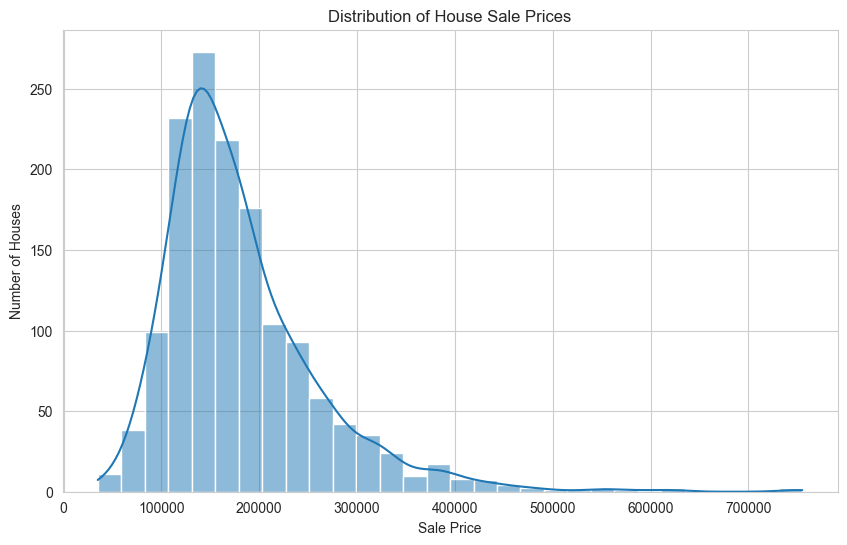

In [16]:
#step 3 EDA 

#  Distribution of SalePrice

plt.figure(figsize=(10, 6))#set graph size as usual
sns.histplot(df["SalePrice"], bins=30, kde=True)#crete hist

plt.title("Distribution of House Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")

plt.show()

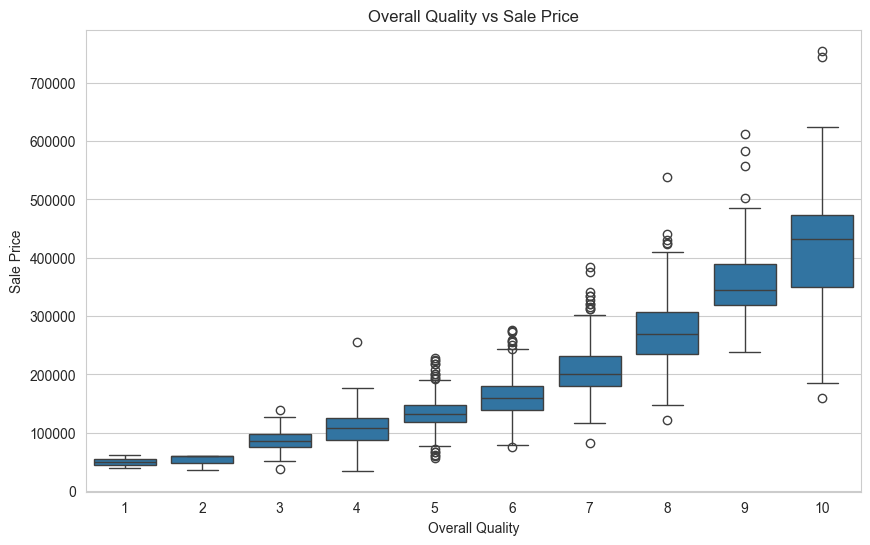

In [17]:
# Overall Quality vs Sale Price

plt.figure(figsize=(10, 6))

sns.boxplot(x="OverallQual", y="SalePrice", data=df)

plt.title("Overall Quality vs Sale Price")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")

plt.show()

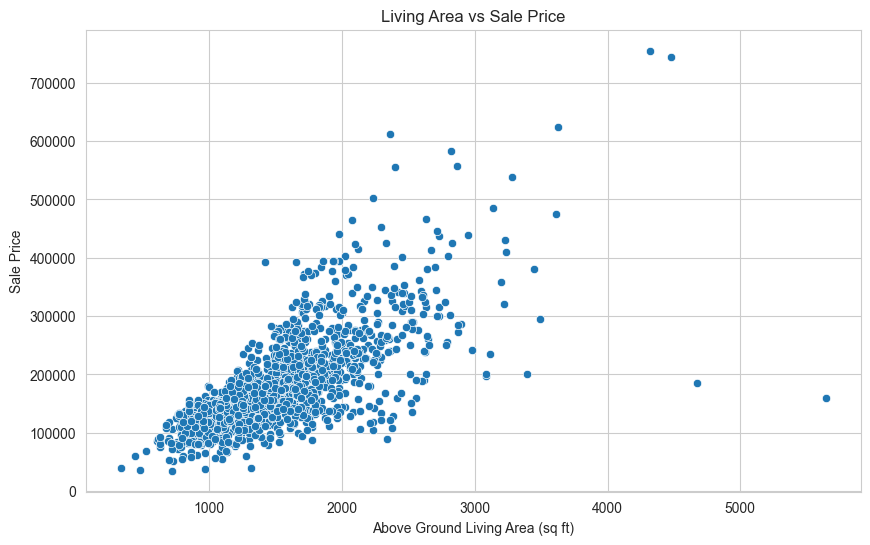

In [22]:
# Living Area vs Sale Price

plt.figure(figsize=(10, 6))

sns.scatterplot(x="GrLivArea", y="SalePrice", data=df)

plt.title("Living Area vs Sale Price")
plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Sale Price")

plt.show()

Step 4 — Correlation Analysis

In [24]:
# Find correlations with SalePrice

correlation = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

print(correlation.head(10))


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


In [27]:
# Top 10 features correlated with SalePrice

top_corr = correlation.head(11)

print(top_corr)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


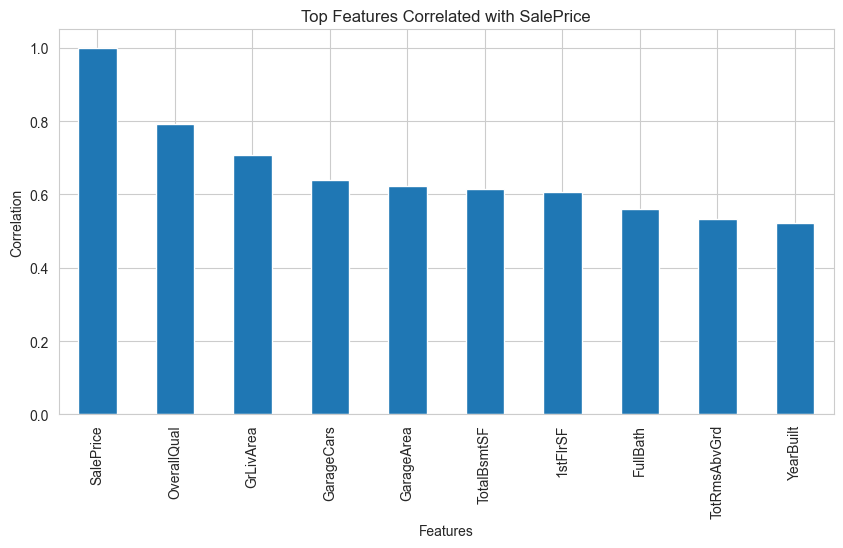

In [25]:
# Plot the top correlated features

correlation.head(10).plot(kind="bar", figsize=(10, 5))

plt.title("Top Features Correlated with SalePrice")
plt.xlabel("Features")
plt.ylabel("Correlation")

plt.show()

Step 5 — Check Missing Values

In [29]:
# Check missing values

missing_values = df.isnull().sum()
print(missing_values)


Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [30]:
 # Check missing values

missing_values = df.isnull().sum()

print(missing_values[missing_values > 0].sort_values(ascending=False))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [31]:
#handles missing value
# Fill missing categorical values

categorical_cols = df.select_dtypes(include="object").columns
df[categorical_cols] = df[categorical_cols].fillna("None")
print("Categorical missing values handled.")

Categorical missing values handled.


In [33]:
# Fill missing numerical values with the median

numerical_cols = df.select_dtypes(include=np.number).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())
print("Numerical missing values handled.")

Numerical missing values handled.


Step 6 — Feature Engineering

In [35]:
# Step 6.1: Create Total house area

df["TotalSF"] = (
    df["TotalBsmtSF"] +
    df["1stFlrSF"] +
    df["2ndFlrSF"]
)

print(df[["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "TotalSF"]].head())

   TotalBsmtSF  1stFlrSF  2ndFlrSF  TotalSF
0          856       856       854     2566
1         1262      1262         0     2524
2          920       920       866     2706
3          756       961       756     2473
4         1145      1145      1053     3343


In [36]:
# Create HouseAge

df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

print(df[["YearBuilt", "YrSold", "HouseAge"]].head())

   YearBuilt  YrSold  HouseAge
0       2003    2008         5
1       1976    2007        31
2       2001    2008         7
3       1915    2006        91
4       2000    2008         8


In [37]:
# Create TotalBathrooms

df["TotalBathrooms"] = (
    df["FullBath"] +
    0.5 * df["HalfBath"] +
    df["BsmtFullBath"] +
    0.5 * df["BsmtHalfBath"]
)

print(df[[
    "FullBath",
    "HalfBath",
    "BsmtFullBath",
    "BsmtHalfBath",
    "TotalBathrooms"
]].head())

   FullBath  HalfBath  BsmtFullBath  BsmtHalfBath  TotalBathrooms
0         2         1             1             0             3.5
1         2         0             0             1             2.5
2         2         1             1             0             3.5
3         1         0             1             0             2.0
4         2         1             1             0             3.5


In [38]:
# Check the new features

print(df[["TotalSF", "HouseAge", "TotalBathrooms"]].head())

   TotalSF  HouseAge  TotalBathrooms
0     2566         5             3.5
1     2524        31             2.5
2     2706         7             3.5
3     2473        91             2.0
4     3343         8             3.5


Step 7 — Separate Features (X) and Target (y)

In [39]:
# Separate features and target now ML

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (1460, 83)
Target (y): (1460,)


In [40]:
# Check the first few rows of X

X.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalSF,HouseAge,TotalBathrooms
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,None,None,0,2,2008,WD,Normal,2566,5,3.5
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,None,None,0,5,2007,WD,Normal,2524,31,2.5
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,None,None,0,9,2008,WD,Normal,2706,7,3.5
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,None,None,0,2,2006,WD,Abnorml,2473,91,2.0
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,None,None,0,12,2008,WD,Normal,3343,8,3.5


In [41]:
# Check the first few values of y

y.head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

Step 8 — Encode Categorical Variables

In [43]:
# Find categorical columns check 

categorical_cols = X.select_dtypes(include="object").columns

print("Number of categorical columns:", len(categorical_cols))
print(categorical_cols.tolist())

Number of categorical columns: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [44]:
# Con?vert categorical columns into numerical columns
#one hot encodde them

X = pd.get_dummies(X, drop_first=True)

print("Shape of X after encoding:", X.shape)

Shape of X after encoding: (1460, 264)


In [45]:
# Check the data types after encoding

print(X.dtypes.value_counts())

bool       224
int64       36
float64      4
Name: count, dtype: int64


Step 9 — Train/Test Split

In [46]:
# Import train_test_split

from sklearn.model_selection import train_test_split

In [47]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1168, 264)
X_test: (292, 264)
y_train: (1168,)
y_test: (292,)


In [48]:
print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 1168
Testing data: 292


Step 10 — Linear Regression

In [49]:
# Import Linear Regression
from sklearn.linear_model import LinearRegression
# Create the Linear Regression model
model = LinearRegression()

In [52]:
# Train the model

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


Step 11 — Make Predictions and Evaluate the Model

In [53]:
 # Make predictions

y_pred = model.predict(X_test)

print("Predictions completed.")
print(y_pred[:5])

Predictions completed.
[160280.58929066 343257.74396176  89964.55692922 176551.47487938
 321041.78036164]


In [54]:
# Compare actual and predicted prices

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,154500,160280.589291
1,325000,343257.743962
2,115000,89964.556929
3,159000,176551.474879
4,315500,321041.780362
5,75500,67931.176818
6,311500,239480.623383
7,146000,146644.894260
8,84500,62691.309629
9,135500,151553.999084


In [55]:
# Calculate RMSE, MAE and R²
# Evaluate the model

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R² Score:", r2)

RMSE: 82993.51319240087
MAE: 23925.507783851604
R² Score: 0.10200387233033092


In [56]:
# Store the results
# Store Linear Regression results

results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "RMSE": [rmse],
    "MAE": [mae],
    "R2": [r2]
})

results



,Model,RMSE,MAE,R2
0,Linear Regression,82993.513192,23925.507784,0.102004


Step 12 — Predicted vs Actual Price

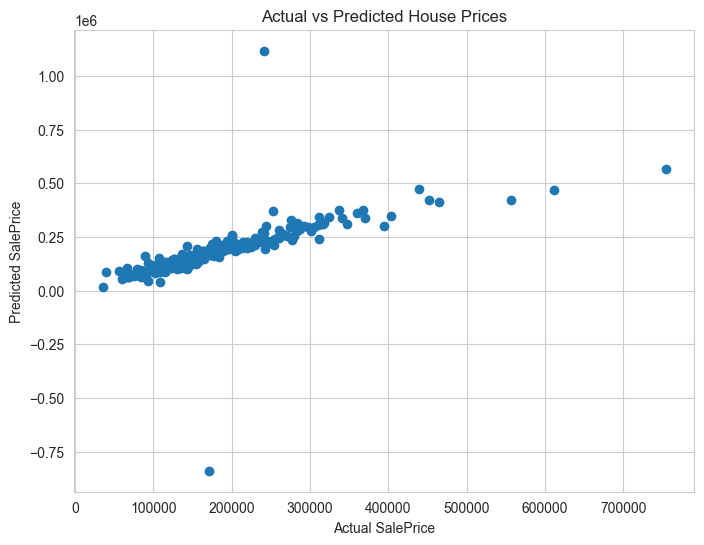

In [57]:
# Plot Actual Price vs Predicted Price

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted House Prices")

plt.show()

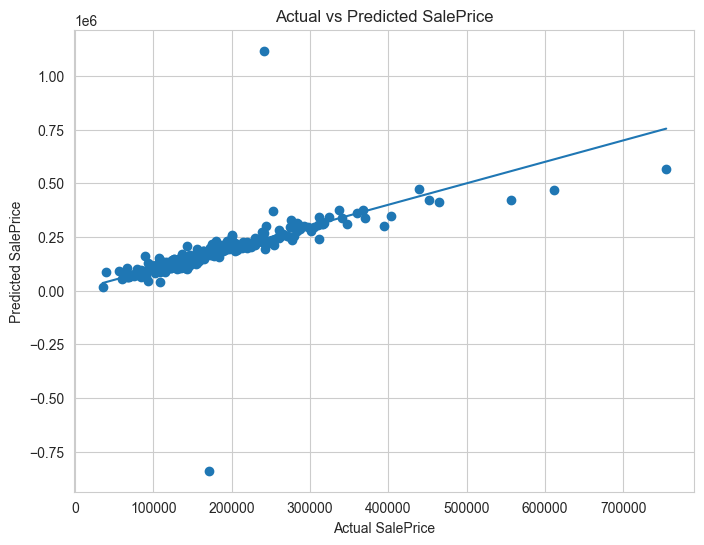

In [58]:
# Add a perfect prediction line

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted SalePrice")

plt.show()

Step 13 — Residual Analysis

In [59]:
# Calculate residuals

residuals = y_test - y_pred

print(residuals.head())

892     -5780.589291
1105   -18257.743962
413     25035.443071
522    -17551.474879
1036    -5541.780362
Name: SalePrice, dtype: float64


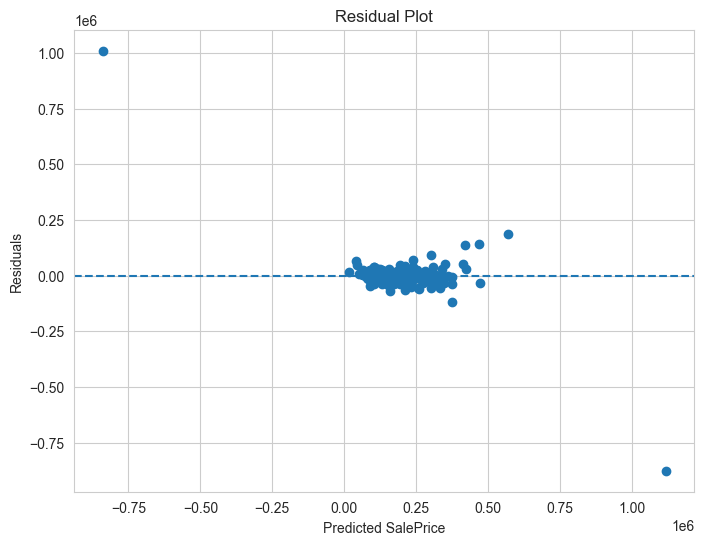

In [60]:
 # Plot residuals

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [61]:
 # Residual summary

print("Mean residual:", residuals.mean())
print("Minimum residual:", residuals.min())
print("Maximum residual:", residuals.max())

Mean residual: 1459.9934755218812
Minimum residual: -876627.2532049129
Maximum residual: 1010483.4752925476


step 14-Ridge Regression

In [62]:
# Import Ridge Regression

from sklearn.linear_model import Ridge
# Create and train Ridge Regression

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

print("Ridge model training completed.")

Ridge model training completed.


In [63]:
# Make Ridge predictions

ridge_pred = ridge_model.predict(X_test)

print(ridge_pred[:5])

[160171.2724759  342320.70302419  92295.935544   185521.4184112
 330116.4011839 ]


In [64]:
# Evaluate Ridge Regression

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge RMSE:", ridge_rmse)
print("Ridge MAE:", ridge_mae)
print("Ridge R²:", ridge_r2)

Ridge RMSE: 30500.6028217295
Ridge MAE: 19761.032180672017
Ridge R²: 0.8787161396581529


In [65]:
# Compare models

results.loc[len(results)] = [
    "Ridge Regression",
    ridge_rmse,
    ridge_mae,
    ridge_r2
]

results

,Model,RMSE,MAE,R2
0,Linear Regression,82993.513192,23925.507784,0.102004
1,Ridge Regression,30500.602822,19761.032181,0.878716


Step 15 — Lasso Regression

In [66]:
# 1: Import Lasso Regression

from sklearn.linear_model import Lasso
# Create and train Lasso Regression

lasso_model = Lasso(alpha=1.0, max_iter=10000)

lasso_model.fit(X_train, y_train)

print("Lasso model training completed.")

Lasso model training completed.


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.045e+11, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


In [68]:
# Make Lasso predictions

lasso_pred = lasso_model.predict(X_test)

print(lasso_pred[:5])

[160969.35877899 348778.79539774  86773.18279578 177766.64369129
 319127.1912631 ]


In [69]:
# Evaluate Lasso Regression

lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso RMSE:", lasso_rmse)
print("Lasso MAE:", lasso_mae)
print("Lasso R²:", lasso_r2)

Lasso RMSE: 37084.84120894668
Lasso MAE: 19199.29752705972
Lasso R²: 0.8207005268949132


In [70]:
# Add Lasso results

results.loc[len(results)] = [
    "Lasso Regression",
    lasso_rmse,
    lasso_mae,
    lasso_r2
]

# results

# Step 16 — Compare All Models
# Linear Regression
# Ridge Regression
# Lasso Regression

In [72]:
results

,Model,RMSE,MAE,R2
0,Linear Regression,82993.513192,23925.507784,0.102004
1,Ridge Regression,30500.602822,19761.032181,0.878716
2,Lasso Regression,37084.841209,19199.297527,0.820701


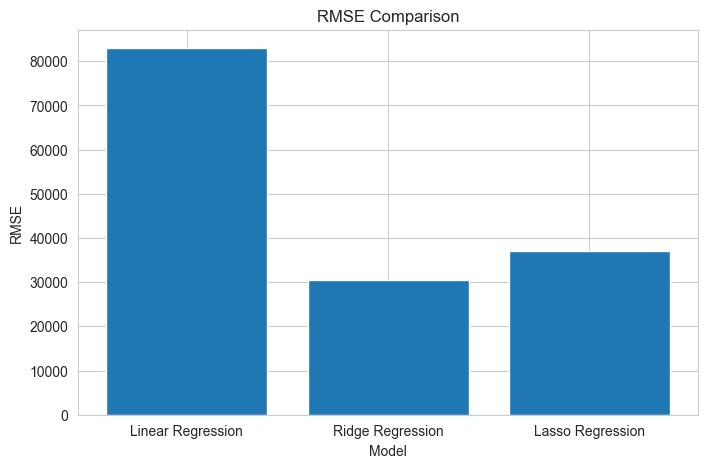

In [74]:
# Compare RMSE

plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["RMSE"])

plt.title("RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.show()

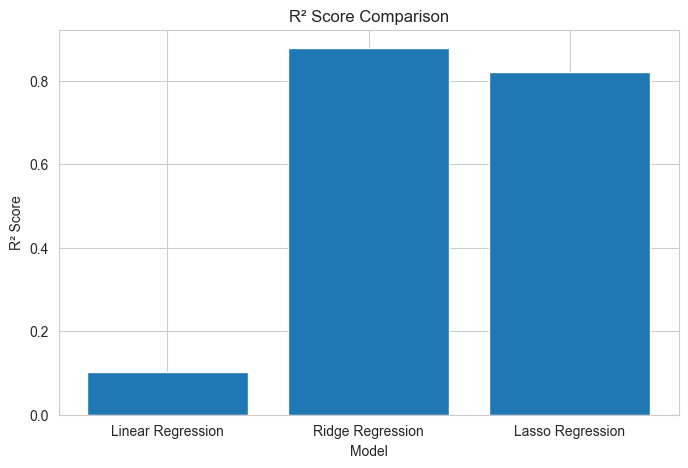

In [75]:
# Compare R²

plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["R2"])

plt.title("R² Score Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.show()

In this project, I predicted house prices using the Ames Housing dataset.
I cleaned the data, handled missing values, created new features, and encoded categorical data.
I trained Linear Regression, Ridge Regression, and Lasso Regression models.
I compared the models using RMSE, MAE, and R² and selected the model with the best performance.
This project helped me understand how machine learning can be used to predict house prices from different house features..